In [1]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_ibm_runtime import SamplerV2, EstimatorV2
from qiskit_aer import AerSimulator

from qiskit.circuit.library import PauliEvolutionGate
from scipy.optimize import minimize
from contextlib import redirect_stderr

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time
import os
import sys

np.random.seed(42)

In [ ]:
class TSPQAOA:
    def __init__(self, W, n_layers=1):
        self.W = W
        self.N = len(W)
        self.n_qubits = (self.N - 1) ** 2
        self.n_layers = n_layers
        self.debug_mode = False

        self.backend = AerSimulator(
            method='matrix_product_state',
            device='CPU'
        ) 
        self.sampler = SamplerV2(mode=self.backend)
        
        # Parâmetros e Operadores
        self.H = self._build_cost_hamiltonian()
        self.gamma = ParameterVector("γ", n_layers)
        self.beta = ParameterVector("β", n_layers)
        
        # Circuito Base (Transpilado uma única vez para performance)
        self.qc_t = self._build_base_circuit()

    def _idx(self, i, p):
        """Mapeia cidade i e posição p para o índice do qubit."""
        return (i - 1) * (self.N - 1) + (p - 1)
    
    def _add_interaction(self, paulis, coeffs, q1, q2, w):
        """Adiciona termo (1-Z1)(1-Z2)/4."""
        for indices, weight in [([q1], -w/4), ([q2], -w/4), ([q1, q2], w/4)]:
            label = ["I"] * self.n_qubits
            for idx in indices: label[idx] = "Z"
            paulis.append("".join(label))
            coeffs.append(weight)

    def _add_linear_term(self, paulis, coeffs, q1, w):
        """Adiciona termo para conexão com cidade fixa (Cidade 0)."""
        label = ["I"] * self.n_qubits
        label[q1] = "Z"
        paulis.append("".join(label))
        coeffs.append(-w/2)    

    def _build_cost_hamiltonian(self):
        """Cria o Hamiltoniano de custo baseado na matriz W."""
        paulis = []
        coeffs = []
        for i in range(1, self.N):
            for j in range(1, self.N):
                if i != j:
                    for p in range(1, self.N - 1):
                        q1 = self._idx(i, p)
                        q2 = self._idx(j, p + 1)
                        self._add_interaction(paulis, coeffs, q1, q2, self.W[i, j])

        for i in range(1, self.N):
            # Cidade 0 (pos 0) -> Cidade i (pos 1)
            self._add_linear_term(paulis, coeffs, self._idx(i, 1), self.W[0, i])
            # Cidade i (pos N-1) -> Cidade 0 (pos 0)
            self._add_linear_term(paulis, coeffs, self._idx(i, self.N - 1), self.W[i, 0])        

        # Penalidade P: deve ser maior que as distâncias em W para desencorajar rotas inválidas
        P = np.max(self.W) * 2

        # 2. PENALIDADES FORTES (Garante 1 bit por linha e 1 por coluna)
        # Para cada posição p, a soma dos qubits deve ser 1
        for p in range(1, self.N):
            # Termo: (Z_i1 + Z_i2 + ... + Z_in - (N-2))^2  <-- Ajustado para mapeamento Ising
            # Simplificando para o seu código adicionar penalidades de par:
            for i in range(1, self.N):
                for j in range(i + 1, self.N):
                    q1, q2 = self._idx(i, p), self._idx(j, p)
                    # Pune se ambos forem 1
                    self._add_interaction(paulis, coeffs, q1, q2, P)
                # Pune se for 0 (Termo linear para forçar o '1')
                label = ["I"] * self.n_qubits
                label[self._idx(i, p)] = "Z"
                paulis.append("".join(label))
                coeffs.append(P / 2) # Ajuste de bias para favorecer bit 1

        return SparsePauliOp(paulis, coeffs).simplify()

    def _apply_xy_mixer(self, qc, beta_val):
        """Aplica o Mixer XY que preserva o peso de Hamming."""
        # Trocas entre cidades para a mesma posição
        for p in range(1, self.N):
            for i in range(1, self.N):
                for j in range(i + 1, self.N):
                    q1, q2 = self._idx(i, p), self._idx(j, p)
                    qc.rxx(2 * beta_val, q1, q2)
                    qc.ryy(2 * beta_val, q1, q2)
        
        # Trocas entre posições para a mesma cidade
        for i in range(1, self.N):
            for p in range(1, self.N):
                for q in range(p + 1, self.N):
                    q1, q2 = self._idx(i, p), self._idx(i, q)
                    qc.rxx(2 * beta_val, q1, q2)
                    qc.ryy(2 * beta_val, q1, q2)

    def _build_base_circuit(self):
        """Constrói o esqueleto do circuito QAOA."""
        qc = QuantumCircuit(self.n_qubits)
        
        # Estado Inicial: Uma cidade em cada posição (Matriz Identidade)
        # IMPORTANTE: ONE-HOT BIT
        for i in range(1, self.N):
            qc.x(self._idx(i, i))
            
        # W-STATE
        # Cria um W-state para cada grupo de posições de uma cidade
        # Para N=4, temos 3 cidades variáveis (1,2,3). Cada uma tem 3 qubits.
        # for i in range(1, self.N):
        #     start_idx = self._idx(i, 1)
        #     # Exemplo simplificado de W-state (3 qubits):
        #     # |100> + |010> + |001>
        #     qc.ry(2 * np.arccos(1/np.sqrt(self.N-1)), start_idx)
        #     qc.ch(start_idx, start_idx + 1)
        #     qc.cx(start_idx + 1, start_idx + 2)
        #     qc.cx(start_idx, start_idx + 1)
        #     qc.x(start_idx)
        #     # Esse bloco acima garante que para a cidade i, apenas um bit p estará ligado.
                
        for l in range(self.n_layers):
            # Evolução do Custo
            evo_gate = PauliEvolutionGate(self.H, time=self.gamma[l])
            qc.append(evo_gate, range(self.n_qubits))
            
            # Mixer XY
            self._apply_xy_mixer(qc, self.beta[l])
            
        return transpile(qc, self.backend)

    def _cost_function(self, params, estimator):
        """Função interna para o otimizador clássico."""
        middle = len(params) // 2

        bound = self.qc_t.assign_parameters({
            self.gamma: params[:middle], 
            self.beta: params[middle:]
        })

        job = estimator.run([(bound, self.H)])
        evs = job.result()[0].data.evs
        if self.debug_mode:
            print(evs)
        return evs

    def debug(self, debug_mode):
        self.debug_mode = debug_mode
    
    def solve(self, max_iter=500):
        """Executa a otimização e retorna os resultados."""
        estimator = EstimatorV2(mode=self.backend)
        
        # Inicialização dos parâmetros
        init_params = np.concatenate([
            np.linspace(0.01, 0.2, self.n_layers),
            np.linspace(0.01, 0.01, self.n_layers)
        ])
        #init_params = [0.5] * self.n_layers * 2
        
        answer = minimize(
            self._cost_function, 
            init_params, 
            args=(estimator), 
            method="COBYLA", 
            options={'maxiter': max_iter}
        )
        
        return answer

    def get_counts(self, optimal_params, shots=10000):
        """Gera a amostragem final com os parâmetros ótimos."""
        final_qc = self.qc_t.assign_parameters({
            self.gamma: optimal_params[:self.n_layers], 
            self.beta: optimal_params[self.n_layers:]
        })
        final_qc.measure_all()
        
        job = self.sampler.run([final_qc], shots=shots)
        return job.result()[0].data.meas.get_counts()
    
    def analyze_routes(self, counts, top_k=10):
        sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_k]
        resultados = []

        for bitstring, freq in sorted_counts:
            bits = bitstring[::-1]
            # Reconstrói a matriz (N-1)x(N-1)
            matriz = np.zeros((self.N, self.N), dtype=int)
            matriz[0, 0] = 1 # Cidade 0 fixa na posição 0
            
            for i in range(1, self.N):
                for p in range(1, self.N):
                    if bits[self._idx(i, p)] == '1':
                        matriz[p, i] = 1

            # Validação
            valido = (np.sum(matriz, axis=0) == 1).all() and (np.sum(matriz, axis=1) == 1).all()
            
            rota, dist = None, None
            if valido:
                rota = [int(np.where(row == 1)[0][0]) for row in matriz]
                dist = sum(self.W[rota[i], rota[(i+1)%self.N]] for i in range(self.N))

            resultados.append({"rota": rota, 'bitstring': bitstring, "distancia": dist, "frequencia": freq, "valido": valido})
        return resultados

In [3]:
def format(ns):
  horas = ns // (3600 * 10**9)
  minutos = (ns // (60 * 10**9)) % 60
  segundos = (ns // 10**9) % 60
  milissegundos = (ns // 10**6) % 1000
  nanosegundos = ns % 10**6

  return f"{horas}h {minutos}m {segundos}s {milissegundos}ms {nanosegundos}ns"

def brute_force_tsp(w):
    from itertools import permutations

    N = len(w)
    a = list(permutations(range(1, N)))
    last_best_distance = 1e10
    for i in a:
        distance = 0
        pre_j = 0
        for j in i:
            distance = distance + w[j, pre_j]
            pre_j = j
        distance = distance + w[pre_j, 0]
        order = (0,) + i
        if distance < last_best_distance:
            best_order = order
            last_best_distance = distance
    return last_best_distance, best_order

def run_silent_qaoa(solver, iterations):
    with open(os.devnull, 'w') as fnull:
        with redirect_stderr(fnull):
            # Tenta executar o solve sem deixar o C++ escrever na tela
            return solver.solve(max_iter=iterations)

In [6]:
if __name__ == "__main__":
    samples = (
        #np.array([[0, 1, 4], [1, 0, 2], [4, 2, 0]]),
        #np.array([[0, 1, 4, 3], [1, 0, 2, 2], [4, 2, 0, 5], [3, 2, 5, 0]]),
        np.array([[0, 1,  4, 3,  7], [1, 0,  2, 2, 10], [4, 2,  0, 5,  8], [3, 2,  5, 0,  6], [7, 10, 8, 6,  0]]),
        #np.array([[0, 5, 8, 4, 5, 6], [5, 0, 4, 7, 5, 4], [8, 4, 0, 5, 6, 4], [4, 7, 5, 0, 4, 8], [5, 5, 6, 4, 0, 5], [6, 4, 4, 8, 5, 0]]),
        #np.array([[0, 6, 8, 5, 7, 6, 9], [6, 0, 5, 7, 6, 5, 8], [8, 5, 0, 6, 8, 5, 7], [5, 7, 6, 0, 5, 9, 6], [7, 6, 8, 5, 0, 6, 5], [6, 5, 5, 9, 6, 0, 7], [9, 8, 7, 6, 5, 7, 0]])
    )

    print('algorithm;vertex;layers;bitstring;rota;distancia;frequencia;status;time_solver;desc_solver;time_optimization;desc_optimization')
    for W in samples:
        start = time.perf_counter_ns()
        distance, route = brute_force_tsp(W)
        time_solver = time.perf_counter_ns() - start 

        print(f'BF;{len(W)};None;None;{list(route)};{distance};None;Válida;{time_solver};{format(time_solver)};None;None')
        
        for n_layer in [1, 2, 3]:
            try:
                solver = TSPQAOA(W, n_layers=n_layer)
                #solver.debug(True)
                
                start = time.perf_counter_ns()
                result = run_silent_qaoa(solver, iterations=500)
                time_solver = time.perf_counter_ns() - start 

                start = time.perf_counter_ns()
                counts = solver.get_counts(result.x)
                time_optimization = time.perf_counter_ns() - start 

                for x in solver.analyze_routes(counts, 10):
                    status = "Válida" if x['valido'] else "Inválida"
                    print(f'QAOA;{len(W)};{n_layer};{x['bitstring']};{x['rota']};{x['distancia']};{x['frequencia']};{status};{time_solver};{format(time_solver)};{time_optimization};{format(time_optimization)}')
            except Exception as e:
                print(e)
                print(f'QAOA;{len(W)};{n_layer};None;None;None;None;{str(e)};None;None;None;None')


algorithm;vertex;layers;bitstring;rota;distancia;frequencia;status;time_solver;desc_solver;time_optimization;desc_optimization
BF;5;None;None;[0, 1, 2, 4, 3];20;None;Válida;191000;0h 0m 0s 0ms 191000ns;None;None
QAOA;5;1;1000010000100001;[0, 1, 2, 3, 4];21;9993;Válida;16413562700;0h 0m 16s 413ms 562700ns;710649400;0h 0m 0s 710ms 649400ns
QAOA;5;1;1000000100100001;None;None;1;Inválida;16413562700;0h 0m 16s 413ms 562700ns;710649400;0h 0m 0s 710ms 649400ns
QAOA;5;1;1000010000100010;None;None;1;Inválida;16413562700;0h 0m 16s 413ms 562700ns;710649400;0h 0m 0s 710ms 649400ns
QAOA;5;1;0000010000101001;None;None;1;Inválida;16413562700;0h 0m 16s 413ms 562700ns;710649400;0h 0m 0s 710ms 649400ns
QAOA;5;1;0100010000100001;None;None;1;Inválida;16413562700;0h 0m 16s 413ms 562700ns;710649400;0h 0m 0s 710ms 649400ns
QAOA;5;1;1000010001000001;None;None;1;Inválida;16413562700;0h 0m 16s 413ms 562700ns;710649400;0h 0m 0s 710ms 649400ns
QAOA;5;1;1100000000100001;None;None;1;Inválida;16413562700;0h 0m 16s 4

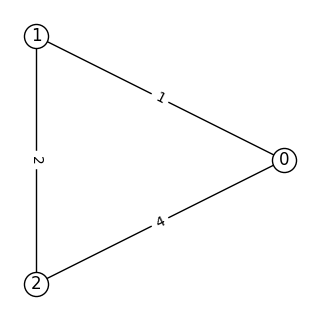

In [27]:
def draw_graph(G):
    plt.figure(figsize=(3, 3))

    layout = nx.circular_layout(G)
    nx.draw(G, layout, 
            with_labels=True, 
            node_color='white', 
            edgecolors='black') # edgecolors mantém a borda visível se desejar
    
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos=layout, edge_labels=labels)
    plt.show()

G = nx.from_numpy_array(W)

draw_graph(G)